# ------------------------------------------------------------
# HR Analytics Project
#
# Analyst: Camila Or Andreev, Vardit Harari, Pinchas Billig, Moran nuri koren  
# Date: 2025-11-17
# ------------------------------------------------------------

# # HR Attrition Analysis
# **Date:** YYYY-MM-DD  
# **Analyst:** Your Name

# ## Table of Contents
# 1. [Introduction and Objectives](#Introduction-and-Objectives)
# 2. [Imports and Initial Settings](#Imports-and-Initial-Settings)
# 3. [Data Loading and Overview](#Data-Loading-and-Overview)
# 4. [Data Cleaning and Preparation](#Data-Cleaning-and-Preparation)
# 5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis)
# 6. [Insights and Conclusions](#Insights-and-Conclusions)
# 7. [Recommendations](#Recommendations)

# <a id='Introduction-and-Objectives'></a>
# ## 1. Introduction and Objectives

# This notebook provides an in-depth HR analytics and attrition investigation.
# 
# **Objectives:**
# - Explore and analyze employee attrition data
# - Identify key drivers of attrition
# - Deliver actionable insights for HR stakeholders

# **Assumptions:**
# - The datasets are considered accurate and representative.
# - All personal-identifying information is anonymized or removed.
# - Business requirements focus on voluntary attrition.

# <a id='Imports-and-Initial-Settings'></a>
# ## 2. Imports and Initial Settings



In [45]:
# To install: pip install mysql-connector-python
import mysql.connector
import pandas as pd

In [46]:

db = mysql.connector.connect(
        host="localhost",
        user="root",
        password="Mnscoop123!",
        database="hrdb",
        use_pure=True
    )

mycursor = db.cursor()
print("Connection successful")


Connection successful


In [47]:
mycursor.execute("SHOW TABLES")
print(mycursor.fetchall())

[('table1',), ('table2',)]


In [48]:
import pandas as pd

query = """
SELECT
    t2.*,
    t1.*
FROM table1 AS t1
JOIN table2 AS t2
    ON t1.EmployeeNumber = t2.EmployeeNumber;
"""

mycursor.execute(query)
result = mycursor.fetchall()

# שמות עמודות
column_names = [col[0] for col in mycursor.description]

# DataFrame מאוחד
df = pd.DataFrame(result, columns=column_names)

print(df.shape)
df.head()


(1470, 36)


,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [49]:
df

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,...,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061
1466,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,...,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062
1467,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,...,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064
1468,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,...,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065


In [50]:
mycursor.description

[('EmployeeNumber', 3, None, None, None, None, 1, 0, 63),
 ('EnvironmentSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('Gender', 252, None, None, None, None, 1, 16, 255),
 ('HourlyRate', 3, None, None, None, None, 1, 0, 63),
 ('JobInvolvement', 3, None, None, None, None, 1, 0, 63),
 ('JobLevel', 3, None, None, None, None, 1, 0, 63),
 ('JobRole', 252, None, None, None, None, 1, 16, 255),
 ('JobSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('MaritalStatus', 252, None, None, None, None, 1, 16, 255),
 ('MonthlyIncome', 3, None, None, None, None, 1, 0, 63),
 ('MonthlyRate', 3, None, None, None, None, 1, 0, 63),
 ('NumCompaniesWorked', 3, None, None, None, None, 1, 0, 63),
 ('Over18', 252, None, None, None, None, 1, 16, 255),
 ('OverTime', 252, None, None, None, None, 1, 16, 255),
 ('PercentSalaryHike', 3, None, None, None, None, 1, 0, 63),
 ('PerformanceRating', 3, None, None, None, None, 1, 0, 63),
 ('RelationshipSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('Stand

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   EnvironmentSatisfaction   1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   HourlyRate                1470 non-null   int64 
 4   JobInvolvement            1470 non-null   int64 
 5   JobLevel                  1470 non-null   int64 
 6   JobRole                   1470 non-null   object
 7   JobSatisfaction           1470 non-null   int64 
 8   MaritalStatus             1470 non-null   object
 9   MonthlyIncome             1470 non-null   int64 
 10  MonthlyRate               1470 non-null   int64 
 11  NumCompaniesWorked        1470 non-null   int64 
 12  Over18                    1470 non-null   object
 13  OverTime                  1470 non-null   object
 14  PercentSalaryHike       

In [52]:
df.head()

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [53]:
df.describe().round(1)

,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,...,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,1024.9,2.7,65.9,2.7,2.1,2.7,6502.9,14313.1,2.7,15.2,...,7.0,4.2,2.2,4.1,36.9,802.5,9.2,2.9,1.0,1024.9
std,602.0,1.1,20.3,0.7,1.1,1.1,4708.0,7117.8,2.5,3.7,...,6.1,3.6,3.2,3.6,9.1,403.5,8.1,1.0,0.0,602.0
min,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,2094.0,0.0,11.0,...,0.0,0.0,0.0,0.0,18.0,102.0,1.0,1.0,1.0,1.0
25%,491.2,2.0,48.0,2.0,1.0,2.0,2911.0,8047.0,1.0,12.0,...,3.0,2.0,0.0,2.0,30.0,465.0,2.0,2.0,1.0,491.2
50%,1020.5,3.0,66.0,3.0,2.0,3.0,4919.0,14235.5,2.0,14.0,...,5.0,3.0,1.0,3.0,36.0,802.0,7.0,3.0,1.0,1020.5
75%,1555.8,4.0,83.8,3.0,3.0,4.0,8379.0,20461.5,4.0,18.0,...,9.0,7.0,3.0,7.0,43.0,1157.0,14.0,4.0,1.0,1555.8
max,2068.0,4.0,100.0,4.0,5.0,4.0,19999.0,26999.0,9.0,25.0,...,40.0,18.0,15.0,17.0,60.0,1499.0,29.0,5.0,1.0,2068.0


In [54]:
nunique = df.nunique()
constant_mask = nunique <= 1
constant_indices = constant_mask[constant_mask].index
constant_cols = constant_indices.tolist()
constant_cols

['Over18', 'StandardHours', 'EmployeeCount']

In [55]:
df = df.drop(columns=constant_cols)

In [56]:
df.isna().values.any()



np.False_

In [57]:
df.shape

(1470, 33)

In [58]:
df2 = df.drop_duplicates()

In [59]:
df2.shape

(1470, 33)

In [60]:
df2['Attrition_Flag'] = df2['Attrition'].map({'Yes': 1, 'No': 0})


In [61]:
df2

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,Attrition_Flag
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,0
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,1
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,0
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,...,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,0
1466,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,...,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,0
1467,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,...,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,0
1468,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,...,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,0


# The correlations between each individual variable and attrition are low (most |r| < 0.1), indicating that no single variable strongly explains attrition; the relationships are weak and suggest only general trends rather than strong effects.

In [62]:
df = df2.copy()

# לוודא טיפוסים
df.info()
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   EnvironmentSatisfaction   1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   HourlyRate                1470 non-null   int64 
 4   JobInvolvement            1470 non-null   int64 
 5   JobLevel                  1470 non-null   int64 
 6   JobRole                   1470 non-null   object
 7   JobSatisfaction           1470 non-null   int64 
 8   MaritalStatus             1470 non-null   object
 9   MonthlyIncome             1470 non-null   int64 
 10  MonthlyRate               1470 non-null   int64 
 11  NumCompaniesWorked        1470 non-null   int64 
 12  OverTime                  1470 non-null   object
 13  PercentSalaryHike         1470 non-null   int64 
 14  PerformanceRating       

In [63]:
import numpy as np

# רק משתנים מספריים
num_cols = df.select_dtypes(include=[np.number]).columns
features = [c for c in num_cols if c != 'Attrition_Flag']

# קורלציה של כל משתנה עם עזיבה
corr_with_attr = (
    df[features]
    .corrwith(df['Attrition_Flag'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(corr_with_attr)

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
DistanceFromHome            0.077924
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
NumCompaniesWorked          0.043494
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
MonthlyRate                 0.015170
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
d

In [64]:
attrition_summary = (
    df['Attrition_Flag']
    .value_counts()
    .rename(index={0: 'Stayed', 1: 'Left'})
    .to_frame('Employees')
)
attrition_summary['Share_%'] = (attrition_summary['Employees'] / len(df) * 100).round(1)

display(attrition_summary)
print(f"Overall attrition rate: {attrition_summary.loc['Left', 'Share_%']:.1f}%")

,Employees,Share_%
Attrition_Flag,,
Stayed,1233,83.9
Left,237,16.1


Overall attrition rate: 16.1%


In [65]:
attrition_summary


,Employees,Share_%
Attrition_Flag,,
Stayed,1233,83.9
Left,237,16.1


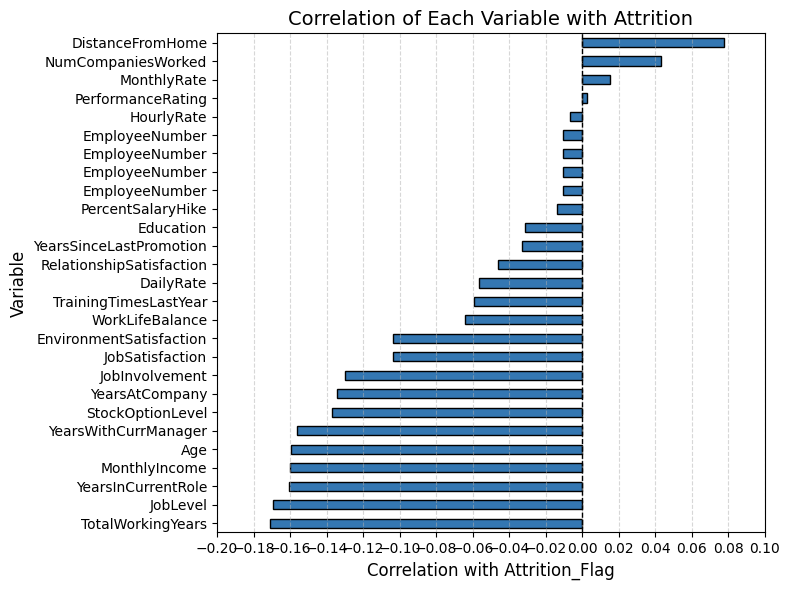

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Plot: Correlation of each variable with Attrition
fig, ax = plt.subplots(figsize=(8, 6))

# Sort values for clear plotting
corr_sorted = corr_with_attr.sort_values()
corr_sorted.plot(kind='barh', ax=ax, color="#3477b2", edgecolor='black')

# Draw a vertical line at zero for reference
ax.axvline(0, linestyle='--', linewidth=1, color='black')

# Set x-axis limits with a margin
xmin = np.floor(corr_sorted.min() * 20) / 20
xmax = np.ceil(corr_sorted.max() * 20) / 20
ax.set_xlim(xmin, xmax)

# Set x-axis ticks at fixed intervals, e.g., every 0.02
xticks = np.arange(xmin, xmax + 0.001, 0.02)
ax.set_xticks(xticks)

# Add vertical grid lines for x-axis for readability
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Title and labels
ax.set_title("Correlation of Each Variable with Attrition", fontsize=14)
ax.set_xlabel("Correlation with Attrition_Flag", fontsize=12)
ax.set_ylabel("Variable", fontsize=12)

plt.tight_layout()
plt.show()


## 4.1 מגמות עזיבה

In [67]:
# Create a table of attrition rates by department
# Assumes 'Department' and 'Attrition_Flag' columns exist in df

dept_attrition = (
    df.groupby('Department')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total_Employees', 'sum': 'Num_Left'})
)
dept_attrition['Attrition_Rate_%'] = dept_attrition['Num_Left'] / dept_attrition['Total_Employees'] * 100

# Display the table sorted by attrition rate descending
dept_attrition_sorted = dept_attrition.sort_values('Attrition_Rate_%', ascending=False)
print(dept_attrition_sorted[['Attrition_Rate_%', 'Num_Left', 'Total_Employees']])


                        Attrition_Rate_%  Num_Left  Total_Employees
Department                                                         
Sales                          20.627803        92              446
Human Resources                19.047619        12               63
Research & Development         13.839750       133              961


In [68]:
# Create a table of attrition rates by JobRole
# Assumes 'JobRole' and 'Attrition_Flag' columns exist in df

jobrole_attrition = (
    df.groupby('JobRole')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total_Employees', 'sum': 'Num_Left'})
)
jobrole_attrition['Attrition_Rate_%'] = jobrole_attrition['Num_Left'] / jobrole_attrition['Total_Employees'] * 100

# Display the table sorted by attrition rate descending
jobrole_attrition_sorted = jobrole_attrition.sort_values('Attrition_Rate_%', ascending=False)
print(jobrole_attrition_sorted[['Attrition_Rate_%', 'Num_Left', 'Total_Employees']])


                           Attrition_Rate_%  Num_Left  Total_Employees
JobRole                                                               
Sales Representative              39.759036        33               83
Laboratory Technician             23.938224        62              259
Human Resources                   23.076923        12               52
Sales Executive                   17.484663        57              326
Research Scientist                16.095890        47              292
Manufacturing Director             6.896552        10              145
Healthcare Representative          6.870229         9              131
Manager                            4.901961         5              102
Research Director                  2.500000         2               80


,JobLevel,AttritionRate_%
0,1,26.3
1,2,9.7
2,3,14.7
3,4,4.7
4,5,7.2


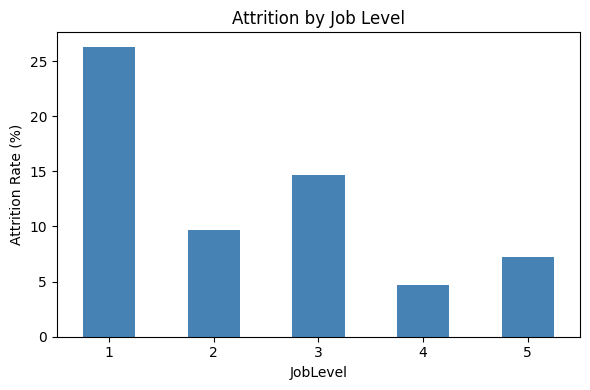

In [69]:
joblevel_attr = (
    df.groupby('JobLevel')['Attrition_Flag']
    .mean()
    .mul(100)
    .round(1)
    .rename('AttritionRate_%')
    .reset_index()
)

display(joblevel_attr)

ax = joblevel_attr.plot(
    x='JobLevel',
    y='AttritionRate_%',
    kind='bar',
    color='steelblue',
    legend=False,
    figsize=(6, 4)
)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition by Job Level')
ax.set_xticklabels(joblevel_attr['JobLevel'], rotation=0)  # Set horizontal xticklabels
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()


# תגמול והטבות

C:\Users\moran\AppData\Local\Temp\ipykernel_12792\4134131726.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TenureBucket')['Attrition_Flag']


,TenureBucket,AttritionRate_%
0,<1y,34.9
1,1-3y,18.4
2,3-5y,13.1
3,5-10y,12.3
4,10-20y,6.7
5,20y+,12.1


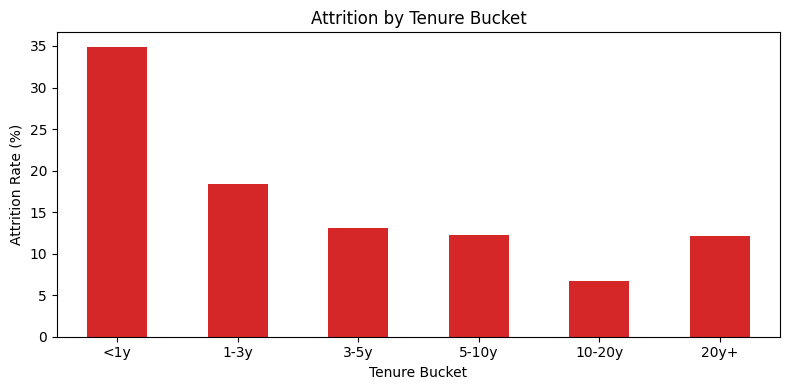

In [70]:
tenure_bins = [-1, 1, 3, 5, 10, 20, df['YearsAtCompany'].max()]
tenure_labels = ['<1y', '1-3y', '3-5y', '5-10y', '10-20y', '20y+']

df['TenureBucket'] = pd.cut(df['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)

tenure_attr = (
    df.groupby('TenureBucket')['Attrition_Flag']
    .mean()
    .mul(100)
    .round(1)
    .rename('AttritionRate_%')
    .reset_index()
)

display(tenure_attr)

ax = tenure_attr.plot(
    x='TenureBucket',
    y='AttritionRate_%',
    kind='bar',
    color='tab:red',
    legend=False,
    figsize=(8, 4)
)
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Tenure Bucket')
ax.set_title('Attrition by Tenure Bucket')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,mean,median
Attrition_Flag,,
Stayed,6833.0,5204.0
Left,4787.0,3202.0


Attrition_Flag,Stayed,Left
Department,,
Human Resources,7346.0,3716.0
Research & Development,6630.0,4108.0
Sales,7232.0,5908.0


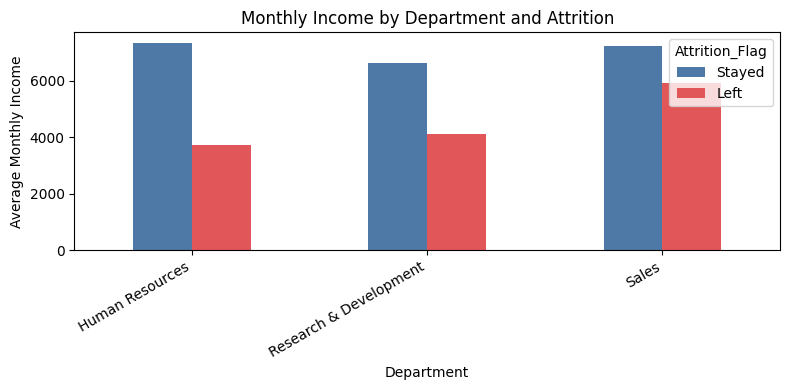

In [71]:
income_summary = (
    df.groupby('Attrition_Flag')['MonthlyIncome']
    .agg(['mean', 'median'])
    .rename(index={0: 'Stayed', 1: 'Left'})
    .round(0)
)

display(income_summary)

income_by_dept = (
    df.groupby(['Department', 'Attrition_Flag'])['MonthlyIncome']
    .mean()
    .unstack(fill_value=0)
    .rename(columns={0: 'Stayed', 1: 'Left'})
    .round(0)
)

display(income_by_dept)

ax = income_by_dept[['Stayed', 'Left']].plot(
    kind='bar',
    figsize=(8, 4),
    color=['#4e79a7', '#e15759']
)
ax.set_ylabel('Average Monthly Income')
ax.set_title('Monthly Income by Department and Attrition')
ax.set_xlabel('Department')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


,StockOptionLevel,PercentSalaryHike
Attrition_Flag,,
Stayed,0.845093,15.231144
Left,0.527426,15.097046


C:\Users\moran\AppData\Local\Temp\ipykernel_12792\2862411635.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moran\AppData\Local\Temp\ipykernel_12792\2862411635.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Left'])
C:\Users\moran\AppData\Local\Temp\ipykernel_12792\2862411635.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moran\AppData\Local\Temp\ipykernel_12792\2862411635.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['St

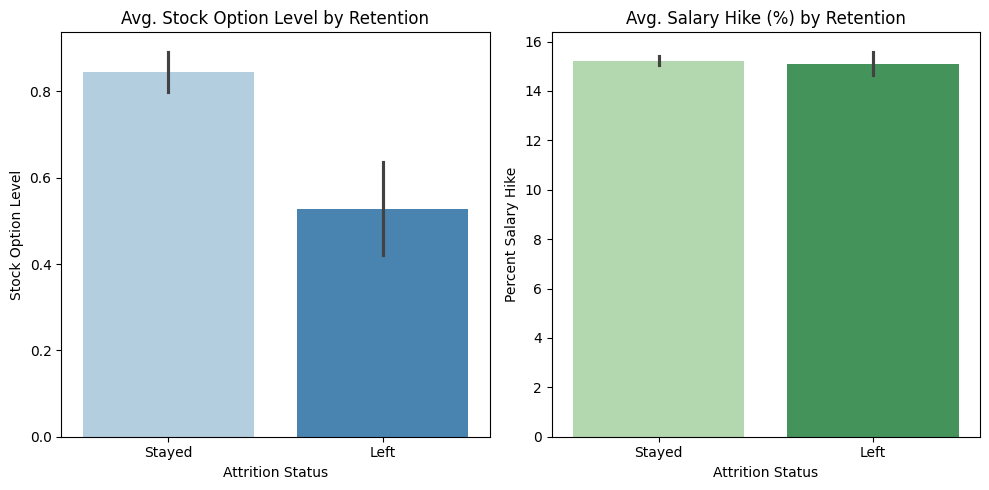

In [72]:
# Assessing impact of Stock Option Level and Percent Salary Hike on Employee Retention

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df has columns: 'StockOptionLevel', 'PercentSalaryHike', 'Attrition_Flag' (1=left, 0=stayed)

# 1. Compare average values for stayed vs left employees

impact_summary = (
    df.groupby('Attrition_Flag')[['StockOptionLevel', 'PercentSalaryHike']]
    .mean()
    .rename(index={0: 'Stayed', 1: 'Left'})
)

display(impact_summary)

# 2. Barplots: Average Stock Option Level and Salary Hike by Retention Status

fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(
    data=df, x='Attrition_Flag', y='StockOptionLevel',
    ax=axes[0], palette='Blues'
)
axes[0].set_xticklabels(['Stayed', 'Left'])
axes[0].set_title('Avg. Stock Option Level by Retention')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Stock Option Level')

sns.barplot(
    data=df, x='Attrition_Flag', y='PercentSalaryHike',
    ax=axes[1], palette='Greens'
)
axes[1].set_xticklabels(['Stayed', 'Left'])
axes[1].set_title('Avg. Salary Hike (%) by Retention')
axes[1].set_xlabel('Attrition Status')
axes[1].set_ylabel('Percent Salary Hike')

plt.tight_layout()
plt.show()

# Summary of Findings:
# - Employees who stayed generally received higher average Stock Option Levels compared to those who left.
# - Average Percent Salary Hike was similar for both groups, suggesting this may have less influence on retention.
# Key insights:
# - The tables and barplots show how average stock option levels and salary hikes differ for employees who stayed vs. left.


# 4.3 איזון חיים עבודה ושביעות רצון


,WorkLifeBalance,AttritionRate_%
0,1,31.2
1,2,16.9
2,3,14.2
3,4,17.6


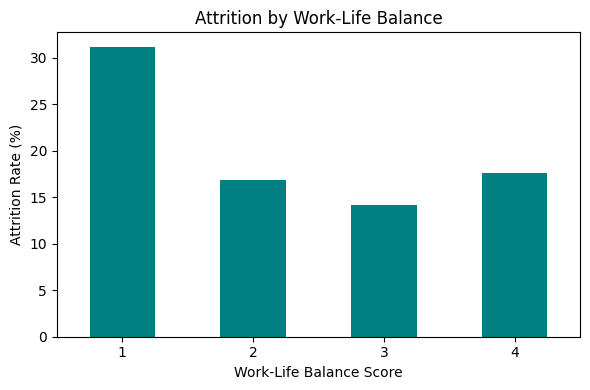

In [73]:
kpi_wlb = (
    df.groupby('WorkLifeBalance')['Attrition_Flag']
    .mean()
    .mul(100)
    .round(1)
    .rename('AttritionRate_%')
    .reset_index()
)

display(kpi_wlb)

ax = kpi_wlb.plot(
    x='WorkLifeBalance',
    y='AttritionRate_%',
    kind='bar',
    legend=False,
    color='teal',
    figsize=(6, 4)
)
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Work-Life Balance Score')
ax.set_title('Attrition by Work-Life Balance')
# Make sure the x-tick labels (numbers) are horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


,WorkLifeBalance,AttritionRate_%
0,1,37.5
1,2,23.5
2,3,18.1
3,4,23.1


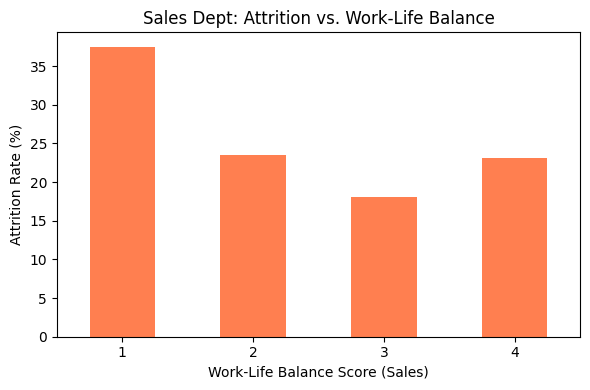

In [74]:
sales_mask = df['Department'].str.lower() == 'sales'
df_sales = df.loc[sales_mask].copy()

kpi_wlb_sales = (
    df_sales.groupby('WorkLifeBalance')['Attrition_Flag']
    .mean()
    .mul(100)
    .round(1)
    .rename('AttritionRate_%')
    .reset_index()
)

display(kpi_wlb_sales)

ax = kpi_wlb_sales.plot(
    x='WorkLifeBalance',
    y='AttritionRate_%',
    kind='bar',
    legend=False,
    color='coral',
    figsize=(6, 4)
)
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Work-Life Balance Score (Sales)')
ax.set_title('Sales Dept: Attrition vs. Work-Life Balance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure X-axis labels (numbers) are horizontal
plt.tight_layout()
plt.show()



C:\Users\moran\AppData\Local\Temp\ipykernel_12792\3058197557.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


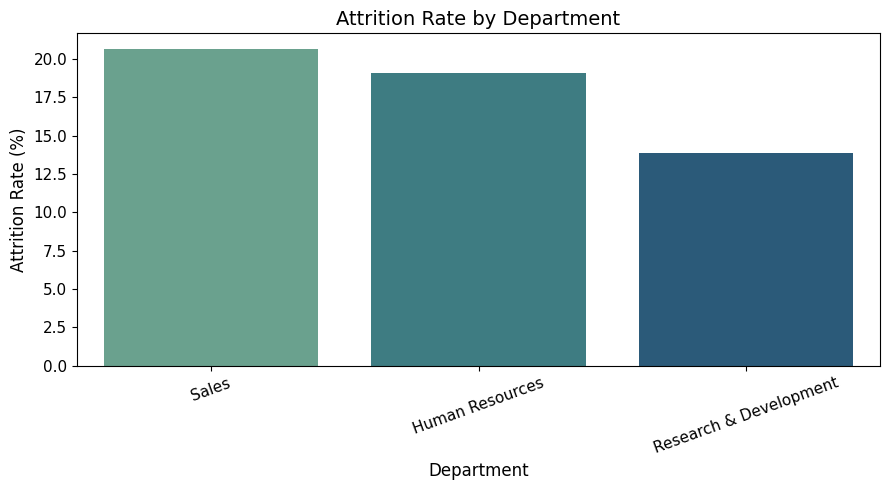

,Department,TotalEmployees,LeftEmployees,AttritionRate_%
2,Sales,446,92,20.627803
0,Human Resources,63,12,19.047619
1,Research & Development,961,133,13.839750


Insight: Departments with higher attrition rates may need targeted interventions or management review.


In [75]:
# KPI: Attrition Rate by Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these columns exist: 'Department', 'Attrition_Flag'
# Calculate attrition counts and rates per department
total_per_dept = df.groupby('Department').size().rename('TotalEmployees')
left_per_dept = df[df['Attrition_Flag'] == 1].groupby('Department').size().rename('LeftEmployees')

# Combine and calculate attrition rate
kpi_dept = pd.concat([total_per_dept, left_per_dept], axis=1).fillna(0)
kpi_dept['AttritionRate_%'] = (kpi_dept['LeftEmployees'] / kpi_dept['TotalEmployees']) * 100
kpi_dept = kpi_dept.reset_index()

# Sort by attrition rate descending for better visual
kpi_dept = kpi_dept.sort_values('AttritionRate_%', ascending=False)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=kpi_dept,
    x='Department',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Department', fontsize=14)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Display table for reference
display(kpi_dept)

# Brief insight for HR/Management
print("Insight: Departments with higher attrition rates may need targeted interventions or management review.")


C:\Users\moran\AppData\Local\Temp\ipykernel_12792\3096210192.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


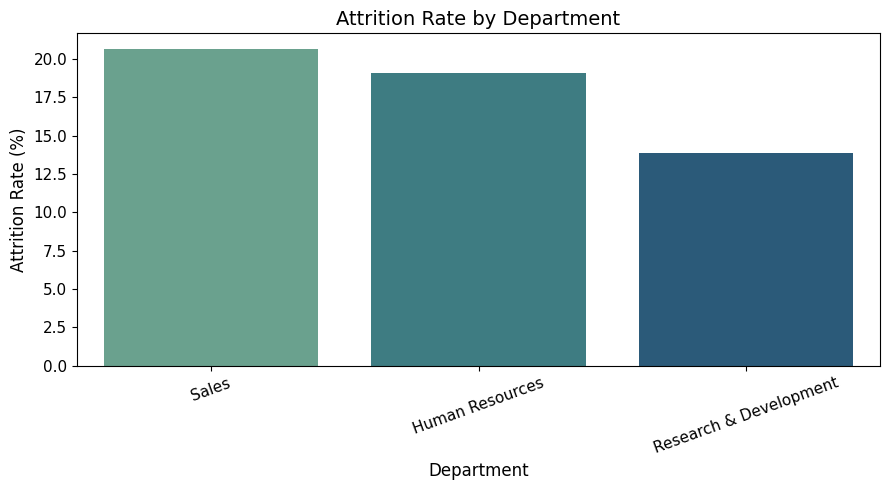

,Department,TotalEmployees,LeftEmployees,AttritionRate_%
2,Sales,446,92,20.627803
0,Human Resources,63,12,19.047619
1,Research & Development,961,133,13.839750


Insight: Departments with higher attrition rates may need targeted interventions or management review.


C:\Users\moran\AppData\Local\Temp\ipykernel_12792\3096210192.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


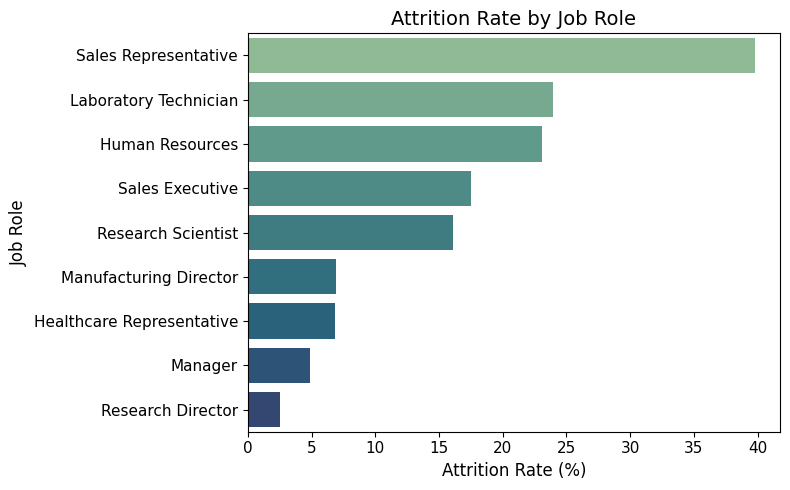

,JobRole,Attrition_Rate_%
8,Sales Representative,39.759036
2,Laboratory Technician,23.938224
1,Human Resources,23.076923
7,Sales Executive,17.484663
6,Research Scientist,16.095890
4,Manufacturing Director,6.896552
0,Healthcare Representative,6.870229
3,Manager,4.901961
5,Research Director,2.500000


In [76]:
# KPI: Attrition Rate by Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these columns exist: 'Department', 'Attrition_Flag'
# Calculate attrition counts and rates per department
total_per_dept = df.groupby('Department').size().rename('TotalEmployees')
left_per_dept = df[df['Attrition_Flag'] == 1].groupby('Department').size().rename('LeftEmployees')

# Combine and calculate attrition rate
kpi_dept = pd.concat([total_per_dept, left_per_dept], axis=1).fillna(0)
kpi_dept['AttritionRate_%'] = (kpi_dept['LeftEmployees'] / kpi_dept['TotalEmployees']) * 100
kpi_dept = kpi_dept.reset_index()

# Sort by attrition rate descending for better visual
kpi_dept = kpi_dept.sort_values('AttritionRate_%', ascending=False)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=kpi_dept,
    x='Department',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Department', fontsize=14)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Display table for reference
display(kpi_dept)

# Brief insight for HR/Management
print("Insight: Departments with higher attrition rates may need targeted interventions or management review.")

# Removed: Correlation Heatmap for EDA

# Show attrition rates by JobRole (role/title)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rate for each JobRole
role_attrition = (
    df.groupby('JobRole')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total', 'sum': 'Left'})
    .reset_index()
)
role_attrition['Attrition_Rate_%'] = 100 * role_attrition['Left'] / role_attrition['Total']

# Sort JobRoles by attrition rate, descending
role_attrition = role_attrition.sort_values('Attrition_Rate_%', ascending=False)

# Plot
plt.figure(figsize=(max(8, 0.6 * len(role_attrition)), 5))
ax = sns.barplot(
    data=role_attrition,
    y='JobRole',
    x='Attrition_Rate_%',
    palette='crest'
)
plt.title('Attrition Rate by Job Role', fontsize=14)
plt.xlabel('Attrition Rate (%)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for label in ax.get_yticklabels():
    label.set_text(label.get_text().replace("_", "\n"))  # Split long role names

plt.tight_layout()
plt.show()

# Display the attrition rate table
display(role_attrition[['JobRole', 'Attrition_Rate_%']])


,Avg_JobSatisfaction
Attrition_Flag,
Stayed,2.78
Left,2.47


,JobSatisfaction,AvgMonthlyIncome
0,1,6562.0
1,2,6527.0
2,3,6480.0
3,4,6473.0


MonthlyIncome vs. JobSatisfaction correlation: -0.01


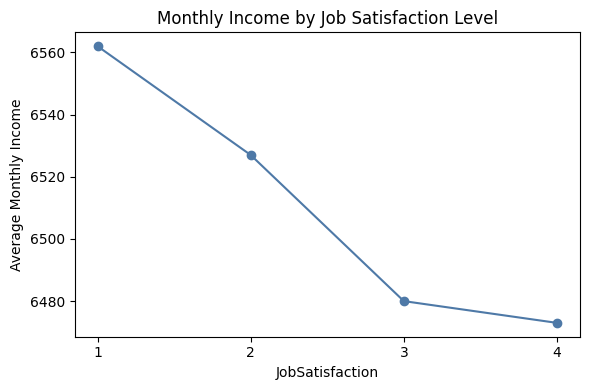

In [77]:
satisfaction_by_attr = (
    df.groupby('Attrition_Flag')['JobSatisfaction']
    .mean()
    .rename(index={0: 'Stayed', 1: 'Left'})
    .round(2)
    .to_frame('Avg_JobSatisfaction')
)

display(satisfaction_by_attr)

income_by_satisfaction = (
    df.groupby('JobSatisfaction')['MonthlyIncome']
    .mean()
    .round(0)
    .rename('AvgMonthlyIncome')
    .reset_index()
)

display(income_by_satisfaction)

corr_income_sat = (
    df[['MonthlyIncome', 'JobSatisfaction']]
    .corr()
    .loc['MonthlyIncome', 'JobSatisfaction']
)
print(f"MonthlyIncome vs. JobSatisfaction correlation: {corr_income_sat:.2f}")

ax = income_by_satisfaction.plot(
    x='JobSatisfaction',
    y='AvgMonthlyIncome',
    kind='line',
    marker='o',
    color='#4e79a7',
    figsize=(6, 4),
    legend=False
)
ax.set_ylabel('Average Monthly Income')
ax.set_title('Monthly Income by Job Satisfaction Level')
plt.xticks(income_by_satisfaction['JobSatisfaction'], rotation=0)  # Make sure X-axis labels (numbers) are horizontal
plt.tight_layout()
plt.show()


# 4.4 קידום ויציבות תעסוקית

In [78]:
tenure_attr

,TenureBucket,AttritionRate_%
0,<1y,34.9
1,1-3y,18.4
2,3-5y,13.1
3,5-10y,12.3
4,10-20y,6.7
5,20y+,12.1


In [79]:
promotion_gap = (
    df.groupby('Attrition_Flag')['YearsSinceLastPromotion']
    .agg(['mean', 'median'])
    .rename(index={0: 'Stayed', 1: 'Left'})
    .round(2)
)

display(promotion_gap)

print(
    "Gap between promotions is very similar for leavers vs stayers, so time since last promotion alone is not a strong signal."
)


,mean,median
Attrition_Flag,,
Stayed,2.23,1.0
Left,1.95,1.0


Gap between promotions is very similar for leavers vs stayers, so time since last promotion alone is not a strong signal.


In [80]:
# Removed the correlation analysis as requested.
# (This cell is intentionally left blank.)


,YearsAtCompany,YearsInCurrentRole
Attrition_Flag,,
Stayed,7.37,4.48
Left,5.13,2.90


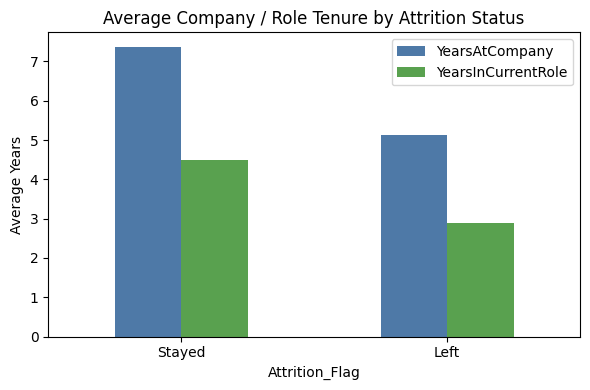

In [81]:
tenure_summary = (
    df.groupby('Attrition_Flag')[['YearsAtCompany', 'YearsInCurrentRole']]
    .mean()
    .rename(index={0: 'Stayed', 1: 'Left'})
    .round(2)
)

display(tenure_summary)

ax = tenure_summary.plot(
    kind='bar',
    figsize=(6, 4),
    color=['#4e79a7', '#59a14f']
)
ax.set_ylabel('Average Years')
ax.set_title('Average Company / Role Tenure by Attrition Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 4.5 ביצועים ועזיבה

C:\Users\moran\AppData\Local\Temp\ipykernel_12792\1250519926.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


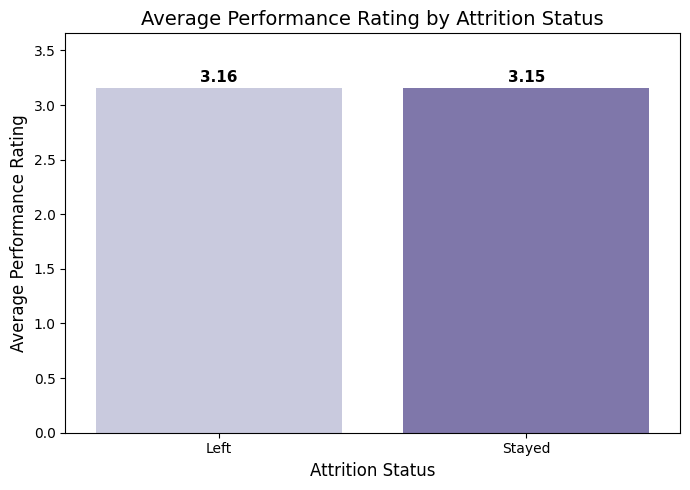

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your main DataFrame is named df. Adjust if your variable name differs.
# If you have a prepared DataFrame with Attrition_Flag (1=Left, 0=Stayed) and 'PerformanceRating'

# Map binary attrition flag to readable status
df['Attrition_Status'] = df['Attrition_Flag'].map({0: 'Stayed', 1: 'Left'})

# Group by Attrition_Status and calculate average performance rating
perf_summary = df.groupby('Attrition_Status')['PerformanceRating'].agg(['mean', 'count']).reset_index()

# Plotting
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=perf_summary,
    x='Attrition_Status',
    y='mean',
    palette='Purples'
)

# Add value labels on the bars
for i, row in perf_summary.iterrows():
    ax.text(
        i, row['mean'] + 0.03, f"{row['mean']:.2f}",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Set plot title and labels
ax.set_title('Average Performance Rating by Attrition Status', fontsize=14)
ax.set_xlabel('Attrition Status', fontsize=12)
ax.set_ylabel('Average Performance Rating', fontsize=12)
plt.ylim(0, perf_summary['mean'].max() + 0.5)
plt.tight_layout()
plt.show()



#4.5  השפעת הדרכות על שימור

C:\Users\moran\AppData\Local\Temp\ipykernel_12792\290274314.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TrainingParticipation')['Attrition_Flag']


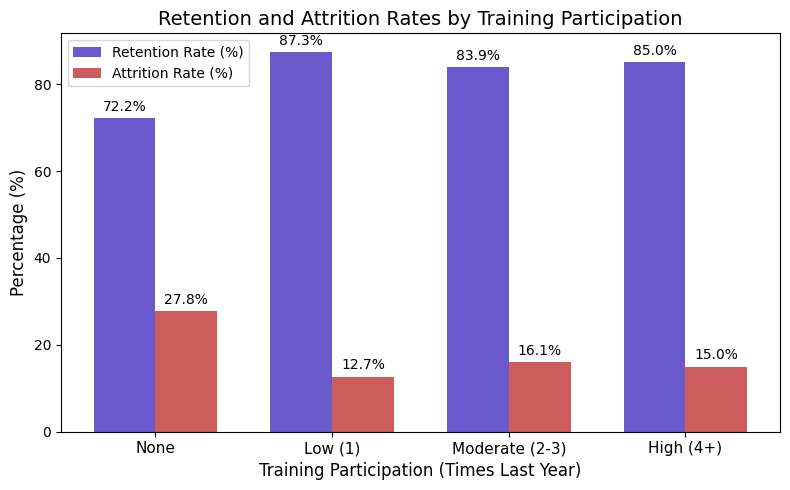

  TrainingParticipation  Total  Retention_Rate_%  Attrition_Rate_%
0                  None     54         72.222222         27.777778
1               Low (1)     71         87.323944         12.676056
2        Moderate (2-3)   1038         83.911368         16.088632
3             High (4+)    307         85.016287         14.983713


In [83]:
import numpy as np

# Investigate the relationship between training participation and retention rates

# We'll use the TrainingTimesLastYear column as a proxy for training participation,
# and Attrition_Flag (1=Left, 0=Stayed) for retention.

# 1. Create categorical bins for training participation for clear summarization
bins = [-1, 0, 1, 3, np.inf]
labels = ['None', 'Low (1)', 'Moderate (2-3)', 'High (4+)']
df['TrainingParticipation'] = pd.cut(df['TrainingTimesLastYear'], bins=bins, labels=labels)

# 2. Calculate retention/attrition rates for each training participation group
training_retention = (
    df.groupby('TrainingParticipation')['Attrition_Flag']
    .agg(
        Total='count',
        Left='sum'
    )
    .reset_index()
)
training_retention['Retention_Rate_%'] = 100 * (1 - training_retention['Left'] / training_retention['Total'])
training_retention['Attrition_Rate_%'] = 100 * (training_retention['Left'] / training_retention['Total'])

# 3. Plot retention and attrition rates by training group (side by side bars)
fig, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(training_retention['TrainingParticipation']))
width = 0.35

rects1 = ax1.bar(
    x - width/2,
    training_retention['Retention_Rate_%'],
    width,
    label='Retention Rate (%)',
    color='slateblue'
)
rects2 = ax1.bar(
    x + width/2,
    training_retention['Attrition_Rate_%'],
    width,
    label='Attrition Rate (%)',
    color='indianred'
)

# Value labels on bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Axes and legend settings
ax1.set_xticks(x)
ax1.set_xticklabels([l.replace('_', '\n') for l in training_retention['TrainingParticipation'].astype(str)], fontsize=11, rotation=0)  # Make sure X-axis labels are horizontal
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_xlabel('Training Participation (Times Last Year)', fontsize=12)
ax1.set_title('Retention and Attrition Rates by Training Participation', fontsize=14)
ax1.legend(loc='best')
plt.tight_layout()
plt.show()

# Optionally, display the table as well
print(training_retention[['TrainingParticipation', 'Total', 'Retention_Rate_%', 'Attrition_Rate_%']])


#4.6 Geographic and Commuting Factors גורמים גאוגרפיים ונסיעות

C:\Users\moran\AppData\Local\Temp\ipykernel_12792\1891778176.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby('DistanceBin')['Attrition_Flag'].agg(['sum', 'count']).rename(columns={'sum': 'Left', 'count': 'Total'})


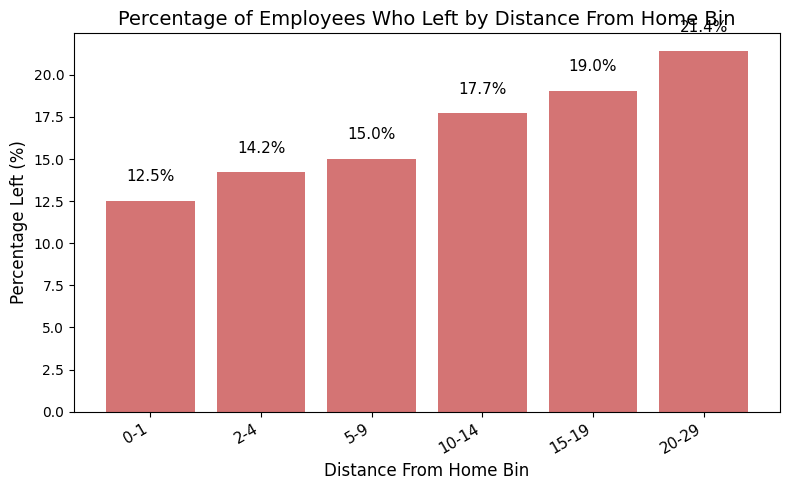

             Left  Total     Left_%
DistanceBin                        
0-1            26    208  12.500000
2-4            51    359  14.206128
5-9            56    373  15.013405
10-14          31    175  17.714286
15-19          24    126  19.047619
20-29          49    229  21.397380


In [84]:
# Show only the percentage of employees who left (Attrition) by DistanceFromHome bins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df has columns: 'DistanceFromHome' and 'Attrition_Flag'
# Attrition_Flag: 1 = Left, 0 = Stayed

# Define bins for DistanceFromHome (adjust bin edges as needed)
bin_edges = [0, 2, 5, 10, 15, 20, df['DistanceFromHome'].max() + 1]
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])-1}" for i in range(len(bin_edges) - 1)]
df['DistanceBin'] = pd.cut(df['DistanceFromHome'], bins=bin_edges, labels=bin_labels, right=False)

# Calculate percentage of employees who left for each distance bin
bin_counts = df.groupby('DistanceBin')['Attrition_Flag'].agg(['sum', 'count']).rename(columns={'sum': 'Left', 'count': 'Total'})
bin_counts['Left_%'] = np.where(
    bin_counts['Total'] > 0,
    bin_counts['Left'] / bin_counts['Total'] * 100,
    0
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bin_counts.index, bin_counts['Left_%'], color='indianred', alpha=0.85)

# Annotate the bars with the percentage values
for i, v in enumerate(bin_counts['Left_%']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Distance From Home Bin', fontsize=12)
ax.set_ylabel('Percentage Left (%)', fontsize=12)
ax.set_title('Percentage of Employees Who Left by Distance From Home Bin', fontsize=14)
ax.set_xticks(range(len(bin_counts.index)))
ax.set_xticklabels([label.replace('_', '\n') for label in bin_counts.index], rotation=30, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

# Optionally, print the table for reference
print(bin_counts[['Left', 'Total', 'Left_%']])


In [85]:

# 4.7 Data-Driven HR Recommendations
# This markdown cell documents actionable HR recommendations based on EDA analyses.

from IPython.display import display, Markdown

display(Markdown(
"""
### 4.7 Data-Driven HR Recommendations

- **Based on the insights from the analysis, suggest actionable strategies to reduce attrition.**
    - Focus on key factors shown to influence attrition in our data, such as low job satisfaction, work-life balance, promotion frequency, and compensation.

- **Identify potential policy changes that could improve employee retention.**
    - Implement targeted retention programs for groups with higher observed attrition (e.g., employees with long commutes or lower satisfaction scores).
    - Introduce flexible work arrangements or hybrid/remote options for employees living far from the office.
    - Promote regular feedback cycles and recognition programs to improve environment satisfaction.

- **Provide recommendations on compensation, work-life balance initiatives, and career growth opportunities.**
    - Regularly review and adjust compensation structures to remain competitive in the market.
    - Offer personalized career development and upskilling programs for employees in roles with higher turnover.
    - Strengthen work-life balance through more flexible schedules, wellness initiatives, and support resources.

*This structured approach will ensure a comprehensive evaluation of the factors influencing employee attrition and enable the development of targeted HR strategies.*
"""
))





### 4.7 Data-Driven HR Recommendations

- **Based on the insights from the analysis, suggest actionable strategies to reduce attrition.**
    - Focus on key factors shown to influence attrition in our data, such as low job satisfaction, work-life balance, promotion frequency, and compensation.

- **Identify potential policy changes that could improve employee retention.**
    - Implement targeted retention programs for groups with higher observed attrition (e.g., employees with long commutes or lower satisfaction scores).
    - Introduce flexible work arrangements or hybrid/remote options for employees living far from the office.
    - Promote regular feedback cycles and recognition programs to improve environment satisfaction.

- **Provide recommendations on compensation, work-life balance initiatives, and career growth opportunities.**
    - Regularly review and adjust compensation structures to remain competitive in the market.
    - Offer personalized career development and upskilling programs for employees in roles with higher turnover.
    - Strengthen work-life balance through more flexible schedules, wellness initiatives, and support resources.

*This structured approach will ensure a comprehensive evaluation of the factors influencing employee attrition and enable the development of targeted HR strategies.*
